Detected 0 outliers in 'TR[K/W]' using a Z-score threshold of 3.


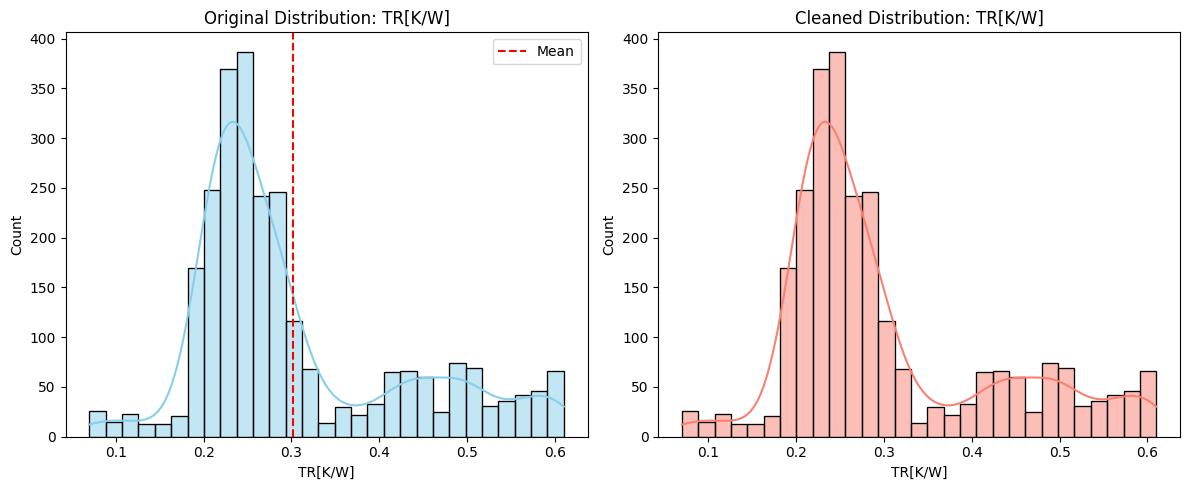

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def clean_column_outliers(df, column_name, threshold=3):
    """
    Identifies and removes outliers from a specific column using Z-scores.
    
    Args:
        df (pd.DataFrame): The input dataframe.
        column_name (str): The column to process.
        threshold (float): The Z-score threshold (default is 3).
        
    Returns:
        pd.DataFrame: A cleaned dataframe with outliers removed.
    """
    
    # 1. Validation: Check if column exists and is numeric
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found.")
        return df
    
    if not np.issubdtype(df[column_name].dtype, np.number):
        print(f"Error: Column '{column_name}' is not numeric.")
        return df

    # Drop NaNs for calculation purposes
    temp_data = df[column_name].dropna()

    # 2. Plotting the distribution before cleaning
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(temp_data, kde=True, color='skyblue')
    plt.axvline(temp_data.mean(), color='red', linestyle='--', label='Mean')
    plt.title(f'Original Distribution: {column_name}')
    plt.legend()

    # 3. Identify Outliers using Z-score
    z_scores = np.abs(stats.zscore(temp_data))
    outliers_mask = z_scores > threshold
    num_outliers = np.sum(outliers_mask)
    
    print(f"Detected {num_outliers} outliers in '{column_name}' using a Z-score threshold of {threshold}.")

    # 4. Remove Outliers
    # We filter the original DF to keep only rows where Z-score is within threshold
    # Note: Rows with NaN in this column are kept by default unless specified otherwise
    df_cleaned = df[(np.abs(stats.zscore(df[column_name])) <= threshold) | (df[column_name].isna())]

    # 5. Plotting the distribution after cleaning
    plt.subplot(1, 2, 2)
    sns.histplot(df_cleaned[column_name].dropna(), kde=True, color='salmon')
    plt.title(f'Cleaned Distribution: {column_name}')
    
    plt.tight_layout()
    plt.show()

    return df_cleaned

# Example usage:
df = pd.read_csv('database.csv')
df_80 = df[df['Q[W]'] == 80]
df_clean_80 = clean_column_outliers(df_80, 'TR[K/W]')

In [8]:
df_80.shape, df_clean_80.shape

((2637, 38), (2637, 38))

Detected 0 outliers in 'TR[K/W]' using a Z-score threshold of 3.


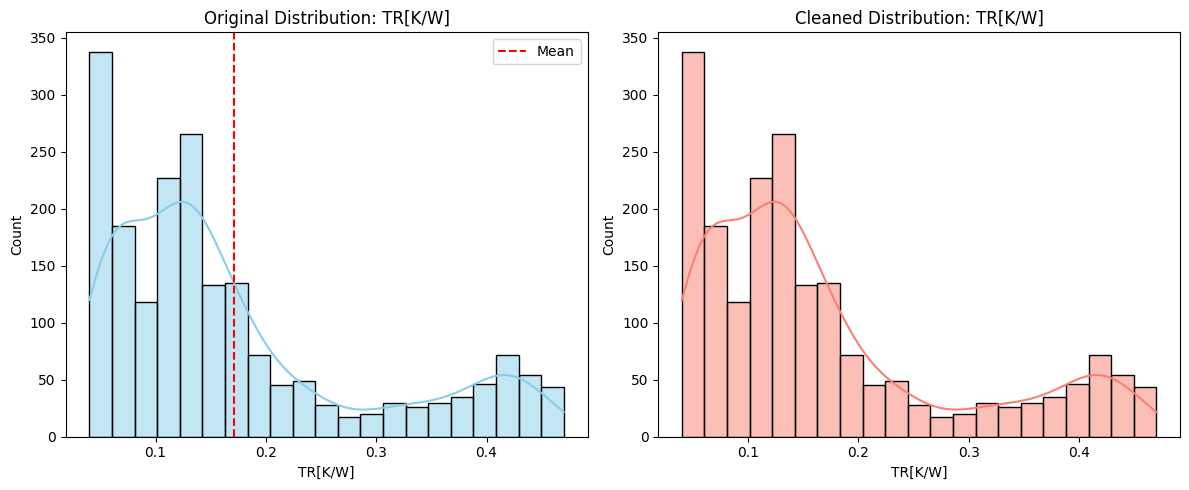

In [9]:
# Example usage:
df = pd.read_csv('database.csv')
df_100 = df[df['Q[W]'] == 100]
df_clean_100 = clean_column_outliers(df_100, 'TR[K/W]')

In [10]:
df_100.shape, df_clean_100.shape

((1970, 38), (1970, 38))

Detected 15 outliers in 'TR[K/W]' using a Z-score threshold of 3.


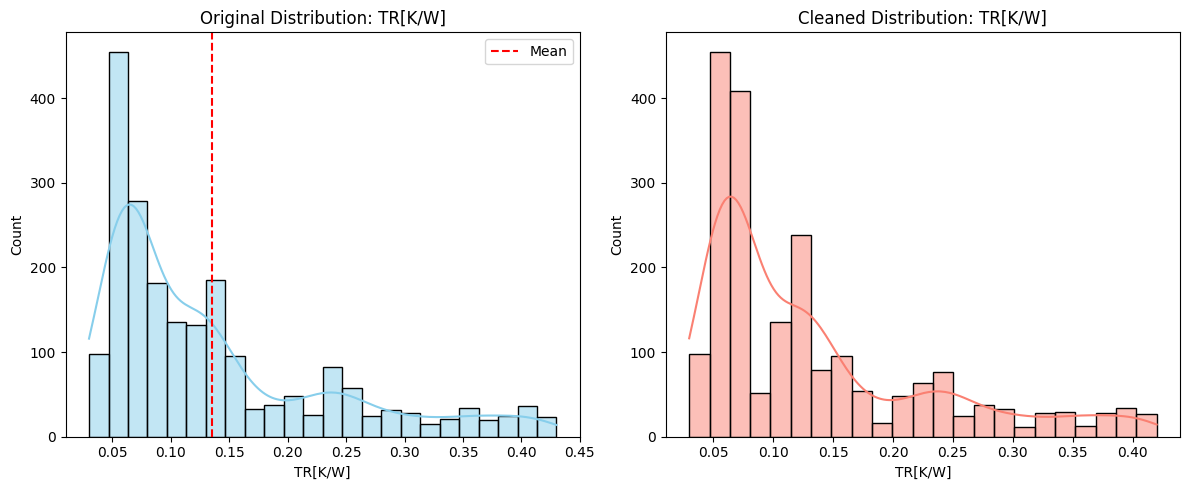

In [13]:
# Example usage:
df = pd.read_csv('database.csv')
df_120 = df[df['Q[W]'] == 120]
df_clean_120 = clean_column_outliers(df_120, 'TR[K/W]')

In [14]:
df_120.shape, df_clean_120.shape

((2101, 38), (2086, 38))

In [15]:
display(df_clean_80)

,TIME,DATE,TC_1,TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,...,P[bar],Te_mean[K],Tc_mean[K],Te_std[K],Tc_std[K],T_pulse[K],TR[K/W],GFE_Te[KJ/mol],GFE_Tc[KJ/mol],dG[KJ/mol]
3621,14:07:55,21/03/2024,31.9,32.2,31.6,31.7,32.0,27.3,26.8,27.1,...,0.56,305.03,299.62,273.39,274.35,0.0,0.07,-1489.64,-1463.24,-26.40
3622,14:07:57,21/03/2024,31.9,32.2,31.6,31.7,32.0,27.3,26.8,27.1,...,0.56,305.03,299.62,273.39,274.35,0.0,0.07,-1489.64,-1463.24,-26.40
3623,14:07:58,21/03/2024,31.9,32.2,31.6,31.7,32.0,27.3,26.8,27.1,...,0.56,305.03,299.65,273.39,274.30,0.0,0.07,-1489.64,-1463.36,-26.27
3624,14:07:59,21/03/2024,31.9,32.2,31.6,31.7,32.0,27.3,26.8,27.1,...,0.56,305.03,299.65,273.39,274.30,0.0,0.07,-1489.64,-1463.36,-26.27
3625,14:08:00,21/03/2024,31.9,32.2,31.6,31.7,32.0,27.3,26.8,27.1,...,0.56,305.03,299.65,273.39,274.30,0.0,0.07,-1489.64,-1463.36,-26.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6253,15:33:52,21/03/2024,88.3,88.7,89.4,90.8,91.0,65.0,64.2,58.0,...,1.40,362.79,339.05,274.37,280.82,0.0,0.30,982.38,918.09,64.28
6254,15:33:53,21/03/2024,88.3,88.7,89.4,90.8,91.0,65.0,64.2,58.0,...,1.40,362.79,339.05,274.37,280.82,0.0,0.30,982.38,918.09,64.28
6255,15:33:56,21/03/2024,89.1,89.1,89.6,91.1,91.4,65.8,64.6,58.0,...,1.40,363.21,339.35,274.26,280.77,0.0,0.30,983.52,918.91,64.61
6256,15:34:01,21/03/2024,89.1,89.1,89.6,91.1,91.4,65.8,64.6,58.0,...,1.42,363.21,339.58,274.26,281.17,0.0,0.30,1026.26,959.48,66.78


In [17]:
df_clean_80.describe()

,TC_1,TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,TC_9,PRESSURE,...,P[bar],Te_mean[K],Tc_mean[K],Te_std[K],Tc_std[K],T_pulse[K],TR[K/W],GFE_Te[KJ/mol],GFE_Tc[KJ/mol],dG[KJ/mol]
count,2637.000000,2637.00000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,...,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.0,2637.000000,2637.000000,2637.000000,2637.000000
mean,81.444444,81.56496,81.828821,83.271217,82.820781,54.845772,65.813841,45.605157,65.799355,0.204710,...,1.214710,355.336045,331.165188,274.167201,285.183951,0.0,0.302177,434.972912,420.144152,14.828840
std,14.201628,14.26430,14.512273,15.035010,15.166736,15.388371,21.807177,12.262887,27.312408,0.337794,...,0.337794,14.625334,18.282890,0.459752,6.394842,0.0,0.120036,960.041964,895.817099,68.345197
min,31.900000,32.20000,31.600000,31.700000,32.000000,27.300000,26.800000,27.100000,24.700000,-0.450000,...,0.560000,305.030000,299.620000,273.340000,274.200000,0.0,0.070000,-1494.620000,-1463.850000,-149.680000
25%,78.700000,78.80000,81.100000,82.400000,80.700000,42.500000,59.500000,31.900000,28.700000,-0.110000,...,0.900000,353.530000,315.350000,273.840000,282.150000,0.0,0.220000,-337.860000,-303.600000,-27.350000
50%,88.200000,89.00000,89.300000,90.800000,90.900000,61.300000,72.200000,46.900000,79.800000,0.400000,...,1.410000,362.910000,341.380000,274.100000,287.330000,0.0,0.260000,1004.190000,948.070000,51.080000
75%,89.900000,90.00000,90.100000,91.600000,91.500000,66.600000,84.700000,57.200000,87.000000,0.460000,...,1.470000,363.690000,344.800000,274.480000,289.330000,0.0,0.350000,1130.480000,1063.280000,59.210000
max,92.500000,91.90000,92.200000,93.700000,93.900000,72.100000,90.100000,63.500000,97.800000,0.600000,...,1.610000,365.910000,349.850000,276.600000,296.400000,0.0,0.610000,1415.000000,1346.660000,81.440000
